# Heart-rate processing for convective-cooling study

This notebook replaces the first draft of `8_heart.ipynb` with a more robust pipeline:

1. Load and quality-check HR traces for every subject-condition pair.
2. Align HR data to the experimental protocol using `session_start_times.csv`.
3. Assign phases using phase intervals inferred from the main processed dataset.
4. Extract physiological features by phase.
5. Merge HR features with thermal/dynamic descriptors.
6. Fit mixed-effects models to test whether ventilation effects remain after accounting for physiological strain.

The goal is not to make another decorative plot. The goal is to separate local cooling from systemic physiological load.


In [58]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, theilslopes

try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False
    warnings.warn("statsmodels is not available. Mixed models will be skipped.")

pd.set_option("display.max_columns", 120)


In [59]:
# =============================================================================
# PATHS
# =============================================================================

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists() or (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Project root not found. Run this notebook inside the repository.")

ROOT = find_project_root()

DATA_PATH = ROOT / "data" / "processed" / "features" / "analysis_dataset_with_tsk.csv"
TESTERS_ROOT = ROOT / "data" / "raw"
SESSION_START_PATH = ROOT / "data" / "raw" / "session_start_times.csv"

# Thermal / dynamic descriptors produced by the current pipeline.
FEATURES_DIR = ROOT / "data" / "processed" / "features"

ANALYSIS_DYNAMIC_PATH = FEATURES_DIR / "analysis_dataset_dynamic.csv"
ANALYSIS_WITH_TSK_PATH = FEATURES_DIR / "analysis_dataset_with_tsk.csv"
BASELINE_VALUES_PATH = FEATURES_DIR / "baseline_values.csv"
DYNAMIC_PHASE_FEATURES_PATH = FEATURES_DIR / "dynamic_phase_features.csv"
PHASE_FEATURES_LONG_PATH = FEATURES_DIR / "phase_features_long.csv"
TRANSITION_K_SUMMARY_PATH = FEATURES_DIR / "transition_k_summary.csv"

# Important: transition_k_summary.csv is condition-phase aggregated.
# It has no subject_id, so it cannot be used for subject-level HR correlations.

OUTPUT_DIR = ROOT / "reports" / "08_heartrate"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUBJECT_COL = "subject_id"
CONDITION_COL = "condition"
PHASE_COL = "phase"
TIME_COL = "elapsed_seconds"

HR_DURATION_MIN = 70
HR_RESAMPLE_SECONDS = 10

# HR.csv assumptions: column A = datetime, column F = heart rate
HR_DATETIME_COL_INDEX = 0
HR_VALUE_COL_INDEX = 5

# Physiological plausibility filters. Adjust only if you have a good reason, not because the data offended you.
HR_MIN_BPM = 35
HR_MAX_BPM = 220
MAX_ALLOWED_GAP_S = 60

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]


# Logical protocol order. Important: standing_2 is the final recovery phase,
# not the second phase alphabetically. Humanity survived another off-by-order error.
PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]


In [60]:
# =============================================================================
# BASIC HELPERS
# =============================================================================

def normalize_id(x) -> str:
    return str(x).strip()


def normalize_condition(x) -> str:
    return str(x).strip()


def canonical_phase_label(x) -> str:
    """Return a consistent phase label when common variants are found."""
    s = str(x).strip().lower()
    s = s.replace("-", "_").replace(" ", "_")
    s = s.replace("walking", "walk")
    s = s.replace("moderate", "moderate")
    s = s.replace("low_intensity", "low")
    s = s.replace("moderate_intensity", "moderate")
    # Common variants from figures/tables.
    aliases = {
        "standing": "standing_1",
        "standing_1": "standing_1",
        "stand_1": "standing_1",
        "standing_initial": "standing_1",
        "walk_low_1": "walk_low_1",
        "walk_a_1": "walk_low_1",
        "walking_a_1": "walk_low_1",
        "walk_moderate_1": "walk_mod_1",
        "walk_b_1": "walk_mod_1",
        "walking_b_1": "walk_mod_1",
        "walk_low_2": "walk_low_2",
        "walk_a_2": "walk_low_2",
        "walking_a_2": "walk_low_2",
        "walk_moderate_2": "walk_mod_2",
        "walk_b_2": "walk_mod_2",
        "walking_b_2": "walk_mod_2",
        "standing_2": "standing_2",
        "stand_2": "standing_2",
        "standing_final": "standing_2",
        "recovery": "standing_2",
    }
    return aliases.get(s, s)


def add_phase_order(df_in: pd.DataFrame, phase_col: str = PHASE_COL) -> pd.DataFrame:
    """Add ordered phase columns for sorting and plotting."""
    out = df_in.copy()
    out[phase_col] = out[phase_col].map(canonical_phase_label)
    order_map = {phase: i for i, phase in enumerate(PHASE_ORDER)}
    out["phase_order"] = out[phase_col].map(order_map).fillna(999).astype(int)
    return out.sort_values(["phase_order", phase_col])


def parse_datetime_series(s: pd.Series) -> pd.Series:
    """Parse HR datetime column robustly and return timezone-naive timestamps."""
    parsed = pd.to_datetime(s, errors="coerce", dayfirst=True, utc=True)
    if parsed.notna().mean() < 0.5:
        parsed = pd.to_datetime(s, errors="coerce", dayfirst=False, utc=True)
    return parsed.dt.tz_convert(None)


def load_session_start_times(path: Path) -> pd.DataFrame:
    session_df = pd.read_csv(path)
    required = [SUBJECT_COL, CONDITION_COL, "start_time"]
    missing = [c for c in required if c not in session_df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}. Available columns: {list(session_df.columns)}")

    session_df = session_df.copy()
    session_df[SUBJECT_COL] = session_df[SUBJECT_COL].map(normalize_id)
    session_df[CONDITION_COL] = session_df[CONDITION_COL].map(normalize_condition)
    session_df["session_start_time"] = pd.to_datetime(session_df["start_time"], errors="coerce", dayfirst=True)
    session_df = session_df.dropna(subset=["session_start_time"])

    duplicated = session_df.duplicated([SUBJECT_COL, CONDITION_COL], keep=False)
    if duplicated.any():
        print("Warning: duplicated session-start rows found. Keeping the first one:")
        display(session_df.loc[duplicated].sort_values([SUBJECT_COL, CONDITION_COL]))
        session_df = session_df.drop_duplicates([SUBJECT_COL, CONDITION_COL], keep="first")

    return session_df


def read_single_hr_file(file: Path) -> pd.DataFrame:
    """Read one CALERA/HR csv file using the known raw structure."""
    hr_df = pd.read_csv(file, skiprows=15, header=None, engine="python", on_bad_lines="skip")
    if hr_df.shape[1] <= HR_VALUE_COL_INDEX:
        raise ValueError(f"HR file has {hr_df.shape[1]} columns, but column F is required: {file}")

    out = pd.DataFrame({
        "hr_datetime": parse_datetime_series(hr_df.iloc[:, HR_DATETIME_COL_INDEX]),
        "HR_bpm_raw": pd.to_numeric(hr_df.iloc[:, HR_VALUE_COL_INDEX], errors="coerce"),
    })
    out = out.dropna(subset=["hr_datetime", "HR_bpm_raw"]).sort_values("hr_datetime")
    out = out.drop_duplicates("hr_datetime")
    return out


def clean_hr_trace(hr: pd.DataFrame) -> pd.DataFrame:
    """Apply conservative HR quality filters and add a smoothed HR signal."""
    hr = hr.copy().sort_values("hr_datetime")
    hr["HR_bpm"] = hr["HR_bpm_raw"].where(hr["HR_bpm_raw"].between(HR_MIN_BPM, HR_MAX_BPM))

    # Remove implausible point-to-point jumps using a robust local median criterion.
    rolling_med = hr["HR_bpm"].rolling(window=11, center=True, min_periods=3).median()
    deviation = (hr["HR_bpm"] - rolling_med).abs()
    mad = deviation.rolling(window=31, center=True, min_periods=5).median()
    spike_mask = deviation > (6 * mad.clip(lower=1.0))
    hr.loc[spike_mask, "HR_bpm"] = np.nan

    # Interpolate only short gaps. Long gaps remain missing.
    dt = hr["hr_datetime"].diff().dt.total_seconds().median()
    if pd.isna(dt) or dt <= 0:
        dt = 1.0
    max_gap_points = max(1, int(MAX_ALLOWED_GAP_S / dt))
    hr["HR_bpm_clean"] = hr["HR_bpm"].interpolate(limit=max_gap_points, limit_direction="both")
    hr["HR_bpm_smooth"] = hr["HR_bpm_clean"].rolling(window=11, center=True, min_periods=3).median()
    return hr


In [61]:
# =============================================================================
# LOAD MAIN DATASET AND PHASE INTERVALS
# =============================================================================

df = pd.read_csv(DATA_PATH)
df[SUBJECT_COL] = df[SUBJECT_COL].map(normalize_id)
df[CONDITION_COL] = df[CONDITION_COL].map(normalize_condition)
df[PHASE_COL] = df[PHASE_COL].map(canonical_phase_label)
df[TIME_COL] = pd.to_numeric(df[TIME_COL], errors="coerce")

print("Main dataset loaded:", df.shape)
display(df[[SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL]].head())


def infer_phase_intervals(main_df: pd.DataFrame) -> pd.DataFrame:
    """Infer phase start/end times from the processed time series."""
    tmp = main_df[[SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL]].dropna().copy()
    tmp[TIME_COL] = pd.to_numeric(tmp[TIME_COL], errors="coerce")
    tmp = tmp.dropna(subset=[TIME_COL])

    rows = []
    for keys, g in tmp.groupby([SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True):
        rows.append({
            SUBJECT_COL: keys[0],
            CONDITION_COL: keys[1],
            PHASE_COL: keys[2],
            "phase_start_s": float(g[TIME_COL].min()),
            "phase_end_s": float(g[TIME_COL].max()),
            "phase_n_main": int(len(g)),
        })
    intervals = pd.DataFrame(rows)
    intervals = add_phase_order(intervals)
    intervals = intervals.sort_values([SUBJECT_COL, CONDITION_COL, "phase_start_s"])

    # Make phase end exclusive using next phase start where possible.
    intervals["phase_end_exclusive_s"] = intervals.groupby([SUBJECT_COL, CONDITION_COL])["phase_start_s"].shift(-1)
    intervals["phase_end_exclusive_s"] = intervals["phase_end_exclusive_s"].fillna(intervals["phase_end_s"] + HR_RESAMPLE_SECONDS)
    return intervals

phase_intervals = infer_phase_intervals(df)
phase_intervals.to_csv(OUTPUT_DIR / "phase_intervals_inferred.csv", index=False)

display(phase_intervals.head(12))


Main dataset loaded: (52199, 28)


,subject_id,condition,phase,elapsed_seconds
0,tester_01,no_wind,standing_1,1.0
1,tester_01,no_wind,standing_1,2.0
2,tester_01,no_wind,standing_1,4.0
3,tester_01,no_wind,standing_1,6.0
4,tester_01,no_wind,standing_1,7.0


,subject_id,condition,phase,phase_start_s,phase_end_s,phase_n_main,phase_order,phase_end_exclusive_s
0,tester_01,no_wind,standing_1,1.0,597.0,300,0,601.0
2,tester_01,no_wind,walk_low_1,601.0,1197.0,300,1,1201.0
4,tester_01,no_wind,walk_mod_1,1201.0,1797.0,300,2,1801.0
3,tester_01,no_wind,walk_low_2,1801.0,2397.0,300,3,2401.0
5,tester_01,no_wind,walk_mod_2,2401.0,2997.0,300,4,3001.0
1,tester_01,no_wind,standing_2,3001.0,3597.0,300,5,3607.0
6,tester_01,wind_high,standing_1,0.0,599.0,360,0,600.0
8,tester_01,wind_high,walk_low_1,600.0,1199.0,360,1,1200.0
10,tester_01,wind_high,walk_mod_1,1200.0,1799.0,360,2,1800.0
9,tester_01,wind_high,walk_low_2,1800.0,2399.0,360,3,2400.0


In [62]:
# =============================================================================
# LOAD AND WINDOW HR DATA
# =============================================================================

def find_hr_file(condition_dir: Path) -> Path | None:
    candidates = [condition_dir / "HR" / "HR.csv", condition_dir / "HR.csv"]
    for c in candidates:
        if c.exists():
            return c
    recursive = list(condition_dir.glob("**/HR.csv"))
    return recursive[0] if recursive else None


def load_all_hr_windows(testers_root: Path, session_start_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_windows = []
    qc_rows = []

    for _, row in session_start_df.iterrows():
        subject_id = row[SUBJECT_COL]
        condition = row[CONDITION_COL]
        start_time = row["session_start_time"]
        end_time = start_time + pd.Timedelta(minutes=HR_DURATION_MIN)

        condition_dir = testers_root / subject_id / condition
        hr_file = find_hr_file(condition_dir)

        qc = {
            SUBJECT_COL: subject_id,
            CONDITION_COL: condition,
            "session_start_time": start_time,
            "hr_file": str(hr_file) if hr_file is not None else None,
            "status": "ok",
        }

        if hr_file is None:
            qc["status"] = "missing_file"
            qc_rows.append(qc)
            print(f"Warning: missing HR file for {subject_id} - {condition}")
            continue

        try:
            hr_full = clean_hr_trace(read_single_hr_file(hr_file))
        except Exception as e:
            qc["status"] = f"read_error: {e}"
            qc_rows.append(qc)
            print(f"Warning: failed reading HR for {subject_id} - {condition}: {e}")
            continue

        hr_window = hr_full[(hr_full["hr_datetime"] >= start_time) & (hr_full["hr_datetime"] < end_time)].copy()
        qc["n_raw_in_window"] = int(len(hr_window))
        qc["coverage_min"] = np.nan

        if hr_window.empty:
            qc["status"] = "empty_window"
            qc_rows.append(qc)
            print(f"Warning: no HR data in expected window for {subject_id} - {condition}")
            continue

        qc["coverage_min"] = (hr_window["hr_datetime"].max() - hr_window["hr_datetime"].min()).total_seconds() / 60
        qc["valid_fraction"] = float(hr_window["HR_bpm_smooth"].notna().mean())

        hr_window[SUBJECT_COL] = subject_id
        hr_window[CONDITION_COL] = condition
        hr_window[TIME_COL] = (hr_window["hr_datetime"] - start_time).dt.total_seconds()
        hr_window["elapsed_bin"] = (np.floor(hr_window[TIME_COL] / HR_RESAMPLE_SECONDS) * HR_RESAMPLE_SECONDS).astype(int)

        hr_10s = (
            hr_window
            .groupby([SUBJECT_COL, CONDITION_COL, "elapsed_bin"], observed=True)
            .agg(
                HR_bpm=("HR_bpm_smooth", "mean"),
                HR_bpm_raw_mean=("HR_bpm_raw", "mean"),
                HR_std_10s=("HR_bpm_smooth", "std"),
                HR_n_10s=("HR_bpm_smooth", "count"),
                hr_datetime_start=("hr_datetime", "min"),
                hr_datetime_end=("hr_datetime", "max"),
            )
            .reset_index()
            .rename(columns={"elapsed_bin": TIME_COL})
        )

        all_windows.append(hr_10s)
        qc["n_10s_bins"] = int(len(hr_10s))
        qc_rows.append(qc)

    if not all_windows:
        raise ValueError("No HR windows were loaded. Check session_start_times.csv and raw HR timestamps.")

    return pd.concat(all_windows, ignore_index=True), pd.DataFrame(qc_rows)

session_start_df = load_session_start_times(SESSION_START_PATH)
hr_10s, hr_qc = load_all_hr_windows(TESTERS_ROOT, session_start_df)

hr_10s.to_csv(OUTPUT_DIR / "HR_10s_by_subject_condition.csv", index=False)
hr_qc.to_csv(OUTPUT_DIR / "HR_loading_QC.csv", index=False)

print("HR 10-s data:", hr_10s.shape)
display(hr_qc)
display(hr_10s.head())


/tmp/ipykernel_244816/1868085046.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(s, errors="coerce", dayfirst=True, utc=True)
/tmp/ipykernel_244816/1868085046.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(s, errors="coerce", dayfirst=True, utc=True)
/tmp/ipykernel_244816/1868085046.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(s, errors="coerce", dayfirst=True, utc=True)


HR 10-s data: (9468, 9)


,subject_id,condition,session_start_time,hr_file,status,n_raw_in_window,coverage_min,valid_fraction,n_10s_bins
0,tester_01,no_wind,2026-04-23 10:02:00,/home/eleonorab/repository/convective_cooling/...,ok,3734,62.216667,1.0,374.0
1,tester_01,wind_low,2026-04-27 09:52:00,/home/eleonorab/repository/convective_cooling/...,ok,3727,62.100000,1.0,373.0
2,tester_02,wind_high,2026-04-29 14:50:00,/home/eleonorab/repository/convective_cooling/...,ok,3690,62.016667,1.0,373.0
3,tester_01,wind_high,2026-04-30 09:56:00,/home/eleonorab/repository/convective_cooling/...,ok,3763,62.700000,1.0,377.0
4,tester_02,no_wind,2026-05-04 14:50:00,/home/eleonorab/repository/convective_cooling/...,ok,3730,62.150000,1.0,373.0
5,tester_03,wind_low,2026-05-06 09:59:00,/home/eleonorab/repository/convective_cooling/...,ok,3711,61.833333,1.0,372.0
6,tester_02,wind_low,2026-05-06 14:47:00,/home/eleonorab/repository/convective_cooling/...,ok,3751,62.500000,1.0,376.0
7,tester_03,no_wind,2026-05-07 10:35:00,/home/eleonorab/repository/convective_cooling/...,ok,3577,59.600000,0.0,359.0
8,tester_04,wind_high,2026-05-07 14:58:00,/home/eleonorab/repository/convective_cooling/...,ok,212,3.516667,1.0,22.0
9,tester_03,wind_high,2026-05-11 10:05:00,/home/eleonorab/repository/convective_cooling/...,empty_window,0,NaN,NaN,NaN


,subject_id,condition,elapsed_seconds,HR_bpm,HR_bpm_raw_mean,HR_std_10s,HR_n_10s,hr_datetime_start,hr_datetime_end
0,tester_01,no_wind,0,102.0,102.0,0.0,10,2026-04-23 10:02:00,2026-04-23 10:02:09
1,tester_01,no_wind,10,102.0,102.0,0.0,10,2026-04-23 10:02:10,2026-04-23 10:02:19
2,tester_01,no_wind,20,102.0,102.0,0.0,10,2026-04-23 10:02:20,2026-04-23 10:02:29
3,tester_01,no_wind,30,102.0,102.0,0.0,10,2026-04-23 10:02:30,2026-04-23 10:02:39
4,tester_01,no_wind,40,102.0,102.0,0.0,10,2026-04-23 10:02:40,2026-04-23 10:02:49


In [63]:
# =============================================================================
# ASSIGN PHASES TO HR DATA USING PHASE INTERVALS
# =============================================================================

def assign_phase_by_intervals(hr_10s: pd.DataFrame, intervals: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (subject, condition), h in hr_10s.groupby([SUBJECT_COL, CONDITION_COL], observed=True):
        ints = intervals[(intervals[SUBJECT_COL] == subject) & (intervals[CONDITION_COL] == condition)]
        if ints.empty:
            print(f"Warning: no phase intervals for {subject}, {condition}")
            continue
        h = h.copy()
        h[PHASE_COL] = pd.NA
        for _, ph in ints.iterrows():
            mask = (h[TIME_COL] >= ph["phase_start_s"]) & (h[TIME_COL] < ph["phase_end_exclusive_s"])
            h.loc[mask, PHASE_COL] = ph[PHASE_COL]
        out.append(h)
    matched = pd.concat(out, ignore_index=True)
    unmatched = matched[PHASE_COL].isna().mean()
    print(f"Unmatched HR bins: {unmatched:.1%}")
    return matched.dropna(subset=[PHASE_COL])

hr_matched = assign_phase_by_intervals(hr_10s, phase_intervals)
hr_matched.to_csv(OUTPUT_DIR / "HR_10s_with_phase.csv", index=False)

display(hr_matched.head())
display(hr_matched.groupby([SUBJECT_COL, CONDITION_COL]).size().reset_index(name="N_10s_bins"))


Unmatched HR bins: 4.0%


,subject_id,condition,elapsed_seconds,HR_bpm,HR_bpm_raw_mean,HR_std_10s,HR_n_10s,hr_datetime_start,hr_datetime_end,phase
1,tester_01,no_wind,10,102.0,102.0,0.0,10,2026-04-23 10:02:10,2026-04-23 10:02:19,standing_1
2,tester_01,no_wind,20,102.0,102.0,0.0,10,2026-04-23 10:02:20,2026-04-23 10:02:29,standing_1
3,tester_01,no_wind,30,102.0,102.0,0.0,10,2026-04-23 10:02:30,2026-04-23 10:02:39,standing_1
4,tester_01,no_wind,40,102.0,102.0,0.0,10,2026-04-23 10:02:40,2026-04-23 10:02:49,standing_1
5,tester_01,no_wind,50,102.0,102.0,0.0,10,2026-04-23 10:02:50,2026-04-23 10:02:59,standing_1


,subject_id,condition,N_10s_bins
0,tester_01,no_wind,360
1,tester_01,wind_high,361
2,tester_01,wind_low,360
3,tester_02,no_wind,360
4,tester_02,wind_high,361
5,tester_02,wind_low,361
6,tester_03,no_wind,336
7,tester_03,wind_low,361
8,tester_04,no_wind,361
9,tester_04,wind_high,22


In [64]:
# =============================================================================
# FEATURE EXTRACTION
# =============================================================================

def first_last_window_mean(g: pd.DataFrame, value_col: str, seconds: int = 60) -> tuple[float, float]:
    t0 = g[TIME_COL].min()
    t1 = g[TIME_COL].max()
    first = g.loc[g[TIME_COL] <= t0 + seconds, value_col].mean()
    last = g.loc[g[TIME_COL] >= t1 - seconds, value_col].mean()
    return first, last


def robust_slope_bpm_per_min(g: pd.DataFrame) -> float:
    g = g[[TIME_COL, "HR_bpm"]].dropna().sort_values(TIME_COL)
    if len(g) < 5 or g["HR_bpm"].nunique() < 2:
        return np.nan
    x_min = (g[TIME_COL].to_numpy() - g[TIME_COL].min()) / 60.0
    y = g["HR_bpm"].to_numpy()
    try:
        return float(theilslopes(y, x_min).slope)
    except Exception:
        return float(np.polyfit(x_min, y, 1)[0])


def summarize_hr_by_phase(hr_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for keys, g in hr_df.groupby([SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True):
        g = g.dropna(subset=["HR_bpm"]).sort_values(TIME_COL)
        if g.empty:
            continue
        first60, last60 = first_last_window_mean(g, "HR_bpm", seconds=60)
        duration_min = (g[TIME_COL].max() - g[TIME_COL].min()) / 60.0
        rows.append({
            SUBJECT_COL: keys[0],
            CONDITION_COL: keys[1],
            PHASE_COL: keys[2],
            "HR_mean_bpm": g["HR_bpm"].mean(),
            "HR_median_bpm": g["HR_bpm"].median(),
            "HR_std_bpm": g["HR_bpm"].std(),
            "HR_min_bpm": g["HR_bpm"].min(),
            "HR_max_bpm": g["HR_bpm"].max(),
            "HR_range_bpm": g["HR_bpm"].max() - g["HR_bpm"].min(),
            "HR_start60_bpm": first60,
            "HR_end60_bpm": last60,
            "HR_delta_end_start_bpm": last60 - first60,
            "HR_slope_bpm_per_min": robust_slope_bpm_per_min(g),
            "HR_AUC_bpm_min": np.trapz(g["HR_bpm"], g[TIME_COL] / 60.0),
            "phase_duration_min_hr": duration_min,
            "HR_n": len(g),
        })
    return pd.DataFrame(rows)

hr_features = summarize_hr_by_phase(hr_matched)

# Baseline correction: phase 1 / first standing phase per subject-condition.
def add_baseline_corrected_hr(features: pd.DataFrame) -> pd.DataFrame:
    features = features.copy()
    ordered = features.sort_values([SUBJECT_COL, CONDITION_COL, PHASE_COL])
    baseline = (
        ordered
        .groupby([SUBJECT_COL, CONDITION_COL], observed=True)
        .first()[["HR_mean_bpm", "HR_start60_bpm"]]
        .rename(columns={"HR_mean_bpm": "HR_baseline_mean_bpm", "HR_start60_bpm": "HR_baseline_start60_bpm"})
        .reset_index()
    )
    features = features.merge(baseline, on=[SUBJECT_COL, CONDITION_COL], how="left")
    features["HR_delta_from_baseline_bpm"] = features["HR_mean_bpm"] - features["HR_baseline_mean_bpm"]
    features["HR_AUC_above_baseline_bpm_min"] = (features["HR_mean_bpm"] - features["HR_baseline_mean_bpm"]) * features["phase_duration_min_hr"]
    return features

hr_features = add_baseline_corrected_hr(hr_features)
hr_features.to_csv(OUTPUT_DIR / "HR_features_by_subject_condition_phase.csv", index=False)

display(hr_features.head(12))


,subject_id,condition,phase,HR_mean_bpm,HR_median_bpm,HR_std_bpm,HR_min_bpm,HR_max_bpm,HR_range_bpm,HR_start60_bpm,HR_end60_bpm,HR_delta_end_start_bpm,HR_slope_bpm_per_min,HR_AUC_bpm_min,phase_duration_min_hr,HR_n,HR_baseline_mean_bpm,HR_baseline_start60_bpm,HR_delta_from_baseline_bpm,HR_AUC_above_baseline_bpm_min
0,tester_01,no_wind,standing_1,88.000833,68.80,31.119666,61.5,152.5,91.0,102.000000,66.700000,-35.300000,-3.942483,865.866667,9.833333,60,88.000833,102.000000,0.000000,0.000000
1,tester_01,no_wind,standing_2,88.875000,88.75,3.604922,74.6,97.0,22.4,93.528571,88.728571,-4.800000,-0.432468,873.700000,9.833333,60,88.000833,102.000000,0.874167,8.595972
2,tester_01,no_wind,walk_low_1,68.963333,69.40,2.922732,62.7,75.0,12.3,64.614286,71.628571,7.014286,0.566137,678.158333,9.833333,60,88.000833,102.000000,-19.037500,-187.202083
3,tester_01,no_wind,walk_low_2,80.548333,80.90,2.418467,75.8,84.6,8.8,81.457143,80.514286,-0.942857,0.150000,791.858333,9.833333,60,88.000833,102.000000,-7.452500,-73.282917
4,tester_01,no_wind,walk_mod_1,81.443333,81.65,3.040928,72.4,87.0,14.6,75.514286,84.885714,9.371429,0.827619,801.266667,9.833333,60,88.000833,102.000000,-6.557500,-64.482083
5,tester_01,no_wind,walk_mod_2,90.010000,90.00,2.947260,80.0,94.6,14.6,85.442857,91.385714,5.942857,0.655180,885.550000,9.833333,60,88.000833,102.000000,2.009167,19.756806
6,tester_01,wind_high,standing_1,72.547778,72.10,6.757278,62.4,88.9,26.5,70.185714,68.857143,-1.328571,-0.023611,713.894444,9.833333,60,72.547778,70.185714,0.000000,0.000000
7,tester_01,wind_high,standing_2,74.378689,73.60,5.035974,64.2,87.5,23.3,84.814286,71.500000,-13.314286,-0.900000,742.850000,10.000000,61,72.547778,70.185714,1.830911,18.309107
8,tester_01,wind_high,walk_low_1,64.845000,65.00,2.535673,60.0,69.7,9.7,63.157143,68.128571,4.971429,0.540000,637.433333,9.833333,60,72.547778,70.185714,-7.702778,-75.743981
9,tester_01,wind_high,walk_low_2,70.920000,70.60,2.428419,66.3,75.8,9.5,74.257143,71.228571,-3.028571,-0.032006,697.133333,9.833333,60,72.547778,70.185714,-1.627778,-16.006481


In [65]:
# =============================================================================
# CONDITION-PHASE SUMMARY
# =============================================================================

hr_condition_phase_summary = (
    hr_features
    .groupby([CONDITION_COL, PHASE_COL], observed=True, sort=False)
    .agg(
        HR_mean_bpm=("HR_mean_bpm", "mean"),
        HR_sd_between_subjects_bpm=("HR_mean_bpm", "std"),
        HR_delta_from_baseline_bpm=("HR_delta_from_baseline_bpm", "mean"),
        HR_slope_bpm_per_min=("HR_slope_bpm_per_min", "mean"),
        HR_AUC_above_baseline_bpm_min=("HR_AUC_above_baseline_bpm_min", "mean"),
        n_subjects=(SUBJECT_COL, "nunique"),
    )
    .reset_index()
)
hr_condition_phase_summary = add_phase_order(hr_condition_phase_summary)
hr_condition_phase_summary = hr_condition_phase_summary.sort_values([CONDITION_COL, "phase_order"])
hr_condition_phase_summary.to_csv(OUTPUT_DIR / "HR_condition_phase_summary.csv", index=False)
display(hr_condition_phase_summary)


,condition,phase,HR_mean_bpm,HR_sd_between_subjects_bpm,HR_delta_from_baseline_bpm,HR_slope_bpm_per_min,HR_AUC_above_baseline_bpm_min,n_subjects,phase_order
0,no_wind,standing_1,88.984881,13.880004,0.000000,-0.319954,0.000000,7,0
2,no_wind,walk_low_1,90.355476,13.782916,1.370595,0.514988,13.477520,7,1
4,no_wind,walk_mod_1,110.049762,20.549554,21.064881,1.715584,207.137996,7,2
3,no_wind,walk_low_2,108.624055,18.276160,19.639174,-0.207980,193.118547,7,3
5,no_wind,walk_mod_2,120.872798,20.892124,31.887917,0.724201,313.564514,7,4
1,no_wind,standing_2,120.520067,19.910513,31.535186,-1.174576,313.530925,7,5
6,wind_high,standing_1,90.798165,22.686385,0.000000,1.623472,0.000000,6,0
8,wind_high,walk_low_1,85.171333,11.771184,3.139444,0.420283,30.871204,5,1
10,wind_high,walk_mod_1,103.395462,16.650206,21.363573,0.934667,210.075132,5,2
9,wind_high,walk_low_2,98.886000,17.146866,16.854111,-0.355079,165.732093,5,3


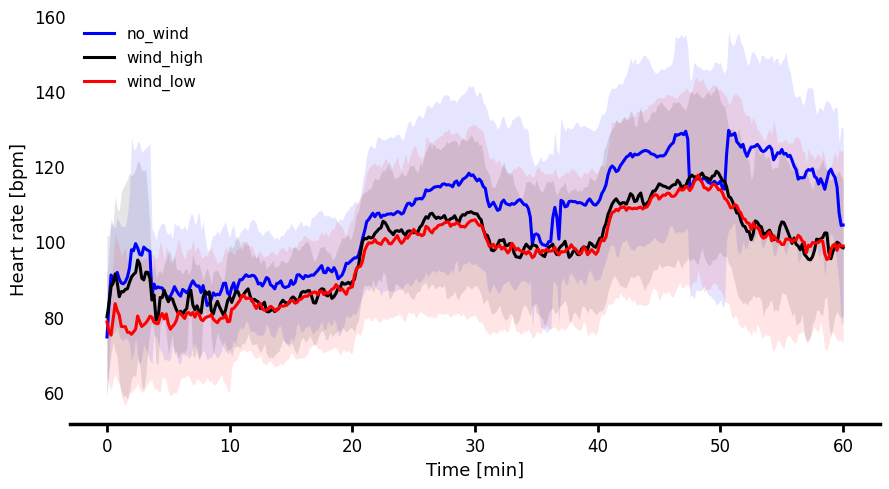

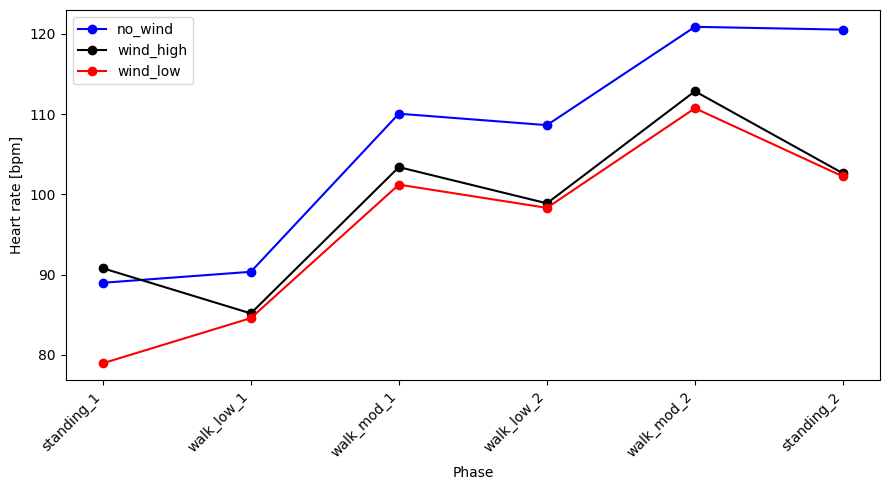

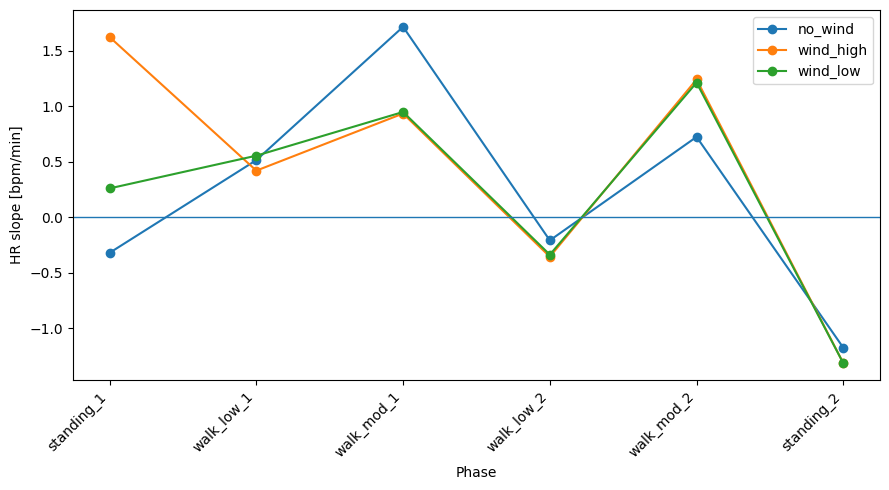

In [93]:
# =============================================================================
# PLOTS: HR TIME SERIES AND PHASE FEATURES
# =============================================================================

def savefig(name: str):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches="tight")
    plt.show()

COLORS = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}

# Mean HR trajectory by condition.
plt.figure(figsize=(9, 5))
ax = plt.gca()

for condition, g in hr_matched.groupby(CONDITION_COL, observed=True):
    mean_trace = (
        g.groupby(TIME_COL, observed=True)["HR_bpm"]
        .agg(["mean", "std"])
        .reset_index()
    )

    ax.plot(
        mean_trace[TIME_COL] / 60,
        mean_trace["mean"],
        label=condition,
        color=COLORS[condition],
        linewidth=2.2,
    )

    ax.fill_between(
        mean_trace[TIME_COL] / 60,
        mean_trace["mean"] - mean_trace["std"],
        mean_trace["mean"] + mean_trace["std"],
        alpha=0.10,
        color=COLORS[condition],
        linewidth=0,
    )

ax.set_xlabel("Time [min]", fontsize=13)
ax.set_ylabel("Heart rate [bpm]", fontsize=13)

# ----- Style -----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_linewidth(2.5)

ax.tick_params(axis="x", width=2, length=6, labelsize=12)
ax.tick_params(axis="y", length=0, labelsize=12)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()

savefig("HR_time_series_mean_by_condition.png")

# Phase means.
plt.figure(figsize=(9, 5))
for condition, g in hr_condition_phase_summary.groupby(CONDITION_COL, observed=True, sort=False):
    g = g.sort_values("phase_order")
    plt.plot(g[PHASE_COL].astype(str), g["HR_mean_bpm"], marker="o", label=condition, color=COLORS[condition])
plt.ylabel("Heart rate [bpm]")
plt.xlabel("Phase")
plt.xticks(rotation=45, ha="right")
plt.legend()
savefig("HR_mean_by_condition_phase.png")

# Phase slopes.
plt.figure(figsize=(9, 5))
for condition, g in hr_condition_phase_summary.groupby(CONDITION_COL, observed=True, sort=False):
    g = g.sort_values("phase_order")
    plt.plot(g[PHASE_COL].astype(str), g["HR_slope_bpm_per_min"], marker="o", label=condition)
plt.axhline(0, linewidth=1)
plt.ylabel("HR slope [bpm/min]")
plt.xlabel("Phase")
plt.xticks(rotation=45, ha="right")
plt.legend()
savefig("HR_slope_by_condition_phase.png")


In [67]:
# =============================================================================
# LOAD THERMAL / DYNAMIC PHASE DESCRIPTORS AND MERGE WITH HR
# =============================================================================
import re

def normalize_phase(x):

    mapping = {
        "standing_1": "standing_1",
        "standing_2": "standing_2",

        "walk_low_1": "walk_low_1",
        "walk_low_2": "walk_low_2",

        "walk_mod_1": "walk_mod_1",
        "walk_mod_2": "walk_mod_2",

        "walk_moderate_1": "walk_mod_1",
        "walk_moderate_2": "walk_mod_2",
    }

    return mapping.get(str(x), str(x))

def read_csv_if_exists(path: Path, required: bool = False) -> pd.DataFrame | None:
    if path.exists():
        print(f"Loading: {path}")
        return pd.read_csv(path)
    msg = f"Missing file: {path}"
    if required:
        raise FileNotFoundError(msg)
    print(msg)
    return None


def normalize_common_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if SUBJECT_COL in df.columns:
        df[SUBJECT_COL] = df[SUBJECT_COL].map(normalize_id)
    if CONDITION_COL in df.columns:
        df[CONDITION_COL] = df[CONDITION_COL].map(normalize_condition)
    if PHASE_COL in df.columns:
        df[PHASE_COL] = df[PHASE_COL].map(normalize_phase)
    return df


def pivot_dynamic_phase_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    dynamic_phase_features.csv is long:
    subject_id, condition, phase, signal, mean, median, p25, p75, mean_last2min, auc.
    Convert it to one row per subject-condition-phase.
    """
    df = normalize_common_columns(df)
    value_cols = [c for c in ["mean", "median", "p25", "p75", "mean_last2min", "auc"] if c in df.columns]
    out = df.pivot_table(
        index=[SUBJECT_COL, CONDITION_COL, PHASE_COL],
        columns="signal",
        values=value_cols,
        aggfunc="first",
        observed=True,
    )
    out.columns = [f"{signal}_{metric}" for metric, signal in out.columns]
    out = out.reset_index()
    return add_phase_order(out)


def pivot_phase_features_long(df: pd.DataFrame) -> pd.DataFrame:
    """
    phase_features_long.csv is long:
    subject_id, condition, phase, signal, mean, std, slope, baseline, etc.
    Convert it to one row per subject-condition-phase.
    """
    df = normalize_common_columns(df)
    value_cols = [c for c in [
        "mean", "std", "median", "min", "max",
        "delta_in_out", "slope", "baseline_value", "delta_mean_from_baseline"
    ] if c in df.columns]
    out = df.pivot_table(
        index=[SUBJECT_COL, CONDITION_COL, PHASE_COL],
        columns="signal",
        values=value_cols,
        aggfunc="first",
        observed=True,
    )
    out.columns = [f"{signal}_{metric}" for metric, signal in out.columns]
    out = out.reset_index()
    return add_phase_order(out)


dynamic_phase_raw = read_csv_if_exists(DYNAMIC_PHASE_FEATURES_PATH)
phase_features_raw = read_csv_if_exists(PHASE_FEATURES_LONG_PATH)
transition_k_summary = read_csv_if_exists(TRANSITION_K_SUMMARY_PATH)

dynamic_tables = []
if dynamic_phase_raw is not None:
    dynamic_tables.append(pivot_dynamic_phase_features(dynamic_phase_raw))
if phase_features_raw is not None:
    dynamic_tables.append(pivot_phase_features_long(phase_features_raw))

if not dynamic_tables:
    dynamic_hr_df = None
    print("No subject-level thermal/dynamic phase feature table found. Correlations will be skipped.")
else:
    # Start from HR features: one row per subject-condition-phase.
    dynamic_hr_df = hr_features.copy()
    for table in dynamic_tables:
        dynamic_hr_df = dynamic_hr_df.merge(
            table.drop(columns=["phase_order"], errors="ignore"),
            on=[SUBJECT_COL, CONDITION_COL, PHASE_COL],
            how="left",
        )

    dynamic_hr_df = add_phase_order(dynamic_hr_df)
    dynamic_hr_df = dynamic_hr_df.sort_values([SUBJECT_COL, CONDITION_COL, "phase_order"])
    dynamic_hr_df.to_csv(OUTPUT_DIR / "thermal_dynamic_HR_dataset.csv", index=False)
    print(f"Merged subject-level HR + thermal/dynamic table: {dynamic_hr_df.shape}")
    display(dynamic_hr_df.head())

if transition_k_summary is not None:
    transition_k_summary = normalize_common_columns(transition_k_summary)
    transition_k_summary = add_phase_order(transition_k_summary)
    print("transition_k_summary.csv loaded only for condition-phase visual comparison, not subject-level correlations.")
    display(transition_k_summary.head())


Loading: /home/eleonorab/repository/convective_cooling/data/processed/features/dynamic_phase_features.csv
Loading: /home/eleonorab/repository/convective_cooling/data/processed/features/phase_features_long.csv
Loading: /home/eleonorab/repository/convective_cooling/data/processed/features/transition_k_summary.csv
Merged subject-level HR + thermal/dynamic table: (121, 219)


,subject_id,condition,phase,HR_mean_bpm,HR_median_bpm,HR_std_bpm,HR_min_bpm,HR_max_bpm,HR_range_bpm,HR_start60_bpm,HR_end60_bpm,HR_delta_end_start_bpm,HR_slope_bpm_per_min,HR_AUC_bpm_min,phase_duration_min_hr,HR_n,HR_baseline_mean_bpm,HR_baseline_start60_bpm,HR_delta_from_baseline_bpm,HR_AUC_above_baseline_bpm_min,delta_t_loc_auc,hti_app_auc,minus_dt_dorsal_dt_auc,delta_t_loc_mean,hti_app_mean,minus_dt_dorsal_dt_mean,delta_t_loc_mean_last2min,hti_app_mean_last2min,minus_dt_dorsal_dt_mean_last2min,delta_t_loc_median,hti_app_median,minus_dt_dorsal_dt_median,delta_t_loc_p25,hti_app_p25,minus_dt_dorsal_dt_p25,delta_t_loc_p75,hti_app_p75,minus_dt_dorsal_dt_p75,mean_skin_temperature_baseline_value,rh_abdomen_baseline_value,rh_chest_baseline_value,rh_dorsal_baseline_value,rh_environment_baseline_value,rh_hand_baseline_value,rh_microclimate_gradient_baseline_value,rh_microclimateback_baseline_value,rh_microclimatefront_baseline_value,rh_neck_baseline_value,rh_shin_baseline_value,t_abdomen_baseline_value,t_chest_baseline_value,t_dorsal_baseline_value,t_environment_baseline_value,t_hand_baseline_value,t_microclimateback_baseline_value,t_microclimatefront_baseline_value,t_neck_baseline_value,t_shin_baseline_value,mean_skin_temperature_delta_in_out,rh_abdomen_delta_in_out,...,rh_abdomen_min,rh_chest_min,rh_dorsal_min,rh_environment_min,rh_hand_min,rh_microclimate_gradient_min,rh_microclimateback_min,rh_microclimatefront_min,rh_neck_min,rh_shin_min,t_abdomen_min,t_chest_min,t_dorsal_min,t_environment_min,t_hand_min,t_microclimateback_min,t_microclimatefront_min,t_neck_min,t_shin_min,mean_skin_temperature_slope,rh_abdomen_slope,rh_chest_slope,rh_dorsal_slope,rh_environment_slope,rh_hand_slope,rh_microclimate_gradient_slope,rh_microclimateback_slope,rh_microclimatefront_slope,rh_neck_slope,rh_shin_slope,t_abdomen_slope,t_chest_slope,t_dorsal_slope,t_environment_slope,t_hand_slope,t_microclimateback_slope,t_microclimatefront_slope,t_neck_slope,t_shin_slope,mean_skin_temperature_std,rh_abdomen_std,rh_chest_std,rh_dorsal_std,rh_environment_std,rh_hand_std,rh_microclimate_gradient_std,rh_microclimateback_std,rh_microclimatefront_std,rh_neck_std,rh_shin_std,t_abdomen_std,t_chest_std,t_dorsal_std,t_environment_std,t_hand_std,t_microclimateback_std,t_microclimatefront_std,t_neck_std,t_shin_std,phase_order
0,tester_01,no_wind,standing_1,88.000833,68.80,31.119666,61.5,152.5,91.0,102.000000,66.700000,-35.300000,-3.942483,865.866667,9.833333,60,88.000833,102.0,0.000000,0.000000,-10.997167,7445.118564,-0.020494,-1.115100,752.109302,-0.002066,-1.151583,1543.054734,-0.000531,-1.203,450.449527,-0.001905,-1.39000,311.125652,-0.003371,-0.89100,947.035508,-0.000962,35.5375,88.752833,83.928917,87.80125,60.043417,76.487333,NaN,83.434417,81.608,75.75975,87.716083,35.805917,36.133583,35.91525,34.275,34.550833,37.066833,37.01575,36.793,35.268667,-0.499,32.278,...,57.022,62.370,64.463,59.286,63.548,NaN,57.012,55.302,49.076,54.972,34.853,34.901,34.683,33.589,33.182,35.637,34.099,35.716,34.967,0.097551,4.091855,2.805660,2.961572,-0.059480,1.248434,NaN,3.189168,3.530952,3.225641,4.165121,0.112565,0.145916,0.148136,0.066278,0.134695,0.202664,0.355835,0.125766,0.034402,0.938281,12.156888,8.535294,8.951665,0.455747,3.942647,NaN,10.836148,10.663587,10.493584,12.488727,0.330827,0.430356,0.442209,0.206262,0.405336,0.660939,1.051667,0.367772,0.111110,0
2,tester_01,no_wind,walk_low_1,68.963333,69.40,2.922732,62.7,75.0,12.3,64.614286,71.628571,7.014286,0.566137,678.158333,9.833333,60,88.000833,102.0,-19.037500,-187.202083,-3.523417,951.921583,-0.003117,-0.356283,158.329994,-0.000312,0.298385,120.908506,-0.000484,-0.518,126.140451,-0.000324,-0.65825,-468.000000,-0.000995,-0.04975,563.947417,0.000196,35.5375,88.752833,83.928917,87.80125,60.043417,76.487333,NaN,83.434417,81.608,75.75975,87.716083,35.805917,36.133583,35.91525,34.275,34.550833,37.066833,37.01575,36.793,35.268667,-1.186,3.698,...,89.621,83.637,87.597,59.286,76.471,NaN,80.026,83.192,79.366,89.709,35.790,35.962,35.806

transition_k_summary.csv loaded only for condition-phase visual comparison, not subject-level correlations.


,phase,condition,n,mean_k,median_k,sd_k,mean_tau,median_tau,mean_r2,median_r2,phase_order
0,standing_1,no_wind,8,0.005868,0.004232,0.006586,1253.510049,248.051244,0.963436,0.982493,0
1,standing_1,wind_low,7,0.009355,0.008013,0.006311,197.870978,124.794005,0.954016,0.962107,0
2,standing_1,wind_high,7,0.006130,0.006870,0.004397,1705.005838,145.559963,0.962723,0.987227,0
3,walk_low_1,no_wind,8,0.004844,0.000090,0.013463,15385.667632,11234.613253,0.799968,0.840099,1
4,walk_low_1,wind_low,7,0.003546,0.000555,0.004267,1598.163940,1800.307134,0.934816,0.933567,1


In [68]:
# =============================================================================
# CORRELATION TABLES: EXPLORATORY SUBJECT-LEVEL ASSOCIATIONS
# =============================================================================

def correlation_table(data: pd.DataFrame, x_cols: list[str], y_cols: list[str], group_col: str | None = None) -> pd.DataFrame:
    rows = []
    groups = [("overall", data)] if group_col is None else list(data.groupby(group_col, observed=True))
    for group_name, g in groups:
        for x in x_cols:
            for y in y_cols:
                if x not in g.columns or y not in g.columns:
                    continue
                tmp = g[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
                if len(tmp) < 6 or tmp[x].nunique() < 2 or tmp[y].nunique() < 2:
                    continue
                pr, pp = pearsonr(tmp[x], tmp[y])
                sr, sp = spearmanr(tmp[x], tmp[y])
                rows.append({
                    "group": group_name,
                    "x": x,
                    "y": y,
                    "n": len(tmp),
                    "pearson_r": pr,
                    "pearson_p": pp,
                    "spearman_rho": sr,
                    "spearman_p": sp,
                })
    return pd.DataFrame(rows).sort_values("spearman_p") if rows else pd.DataFrame()

if dynamic_hr_df is not None:
    hr_cols = [c for c in [
        "HR_mean_bpm",
        "HR_delta_from_baseline_bpm",
        "HR_slope_bpm_per_min",
        "HR_AUC_above_baseline_bpm_min",
        "HR_delta_end_start_bpm",
    ] if c in dynamic_hr_df.columns]

    # These names match the actual uploaded feature tables after pivoting.
    candidate_y = [
        # From dynamic_phase_features.csv
        "delta_t_loc_mean",
        "delta_t_loc_mean_last2min",
        "delta_t_loc_auc",
        "delta_t_loc_median",
        # From phase_features_long.csv
        "t_dorsal_mean",
        "t_dorsal_slope",
        "t_dorsal_delta_in_out",
        "t_dorsal_delta_mean_from_baseline",
        "t_microclimateback_mean",
        "t_microclimateback_slope",
        "t_microclimateback_delta_in_out",
        "t_microclimateback_delta_mean_from_baseline",
        "mean_skin_temperature_mean",
        "mean_skin_temperature_slope",
        "mean_skin_temperature_delta_in_out",
        "mean_skin_temperature_delta_mean_from_baseline",
        "rh_microclimateback_mean",
        "rh_microclimateback_slope",
        "rh_microclimateback_delta_mean_from_baseline",
    ]
    y_cols = [c for c in candidate_y if c in dynamic_hr_df.columns]

    print("HR columns used:", hr_cols)
    print("Thermal/dynamic columns used:", y_cols)

    corr_overall = correlation_table(dynamic_hr_df, hr_cols, y_cols)
    corr_by_condition = correlation_table(dynamic_hr_df, hr_cols, y_cols, group_col=CONDITION_COL)
    corr_by_phase = correlation_table(dynamic_hr_df, hr_cols, y_cols, group_col=PHASE_COL)

    corr_overall.to_csv(OUTPUT_DIR / "HR_thermal_correlations_overall.csv", index=False)
    corr_by_condition.to_csv(OUTPUT_DIR / "HR_thermal_correlations_by_condition.csv", index=False)
    corr_by_phase.to_csv(OUTPUT_DIR / "HR_thermal_correlations_by_phase.csv", index=False)

    display(corr_overall.head(20))
else:
    print("No merged HR + thermal/dynamic dataset available.")


HR columns used: ['HR_mean_bpm', 'HR_delta_from_baseline_bpm', 'HR_slope_bpm_per_min', 'HR_AUC_above_baseline_bpm_min', 'HR_delta_end_start_bpm']
Thermal/dynamic columns used: ['delta_t_loc_mean', 'delta_t_loc_mean_last2min', 'delta_t_loc_auc', 'delta_t_loc_median', 't_dorsal_mean', 't_dorsal_slope', 't_dorsal_delta_in_out', 't_dorsal_delta_mean_from_baseline', 't_microclimateback_mean', 't_microclimateback_slope', 't_microclimateback_delta_in_out', 't_microclimateback_delta_mean_from_baseline', 'mean_skin_temperature_mean', 'mean_skin_temperature_slope', 'mean_skin_temperature_delta_in_out', 'mean_skin_temperature_delta_mean_from_baseline', 'rh_microclimateback_mean', 'rh_microclimateback_slope', 'rh_microclimateback_delta_mean_from_baseline']


,group,x,y,n,pearson_r,pearson_p,spearman_rho,spearman_p
73,overall,HR_AUC_above_baseline_bpm_min,rh_microclimateback_mean,121,0.511664,2.000016e-09,0.620160,3.312074e-14
35,overall,HR_delta_from_baseline_bpm,rh_microclimateback_mean,121,0.511227,2.075065e-09,0.618428,4.084915e-14
75,overall,HR_AUC_above_baseline_bpm_min,rh_microclimateback_delta_mean_from_baseline,121,0.403356,4.490209e-06,0.524870,6.410716e-10
37,overall,HR_delta_from_baseline_bpm,rh_microclimateback_delta_mean_from_baseline,121,0.403228,4.524401e-06,0.523030,7.534408e-10
12,overall,HR_mean_bpm,mean_skin_temperature_mean,121,0.465764,7.309701e-08,0.470621,5.119069e-08
16,overall,HR_mean_bpm,rh_microclimateback_mean,121,0.450313,2.190086e-07,0.437095,5.368776e-07
89,overall,HR_delta_end_start_bpm,mean_skin_temperature_slope,121,0.322444,3.098749e-04,0.422382,1.394546e-06
51,overall,HR_slope_bpm_per_min,mean_skin_temperature_slope,121,0.325697,2.669744e-04,0.406673,3.680965e-06
31,overall,HR_delta_from_baseline_bpm,mean_skin_temperature_mean,121,0.345952,1.016222e-04,0.379361,1.777180e-05
69,overall,HR_AUC_above_baseline_bpm_min,mean_skin_temperature_mean,121,0.346407,9.936282e-05,0.379191,1.793887e-05


In [69]:
# =============================================================================
# MIXED MODELS: DOES VENTILATION STILL MATTER AFTER HR?
# =============================================================================

if dynamic_hr_df is not None and HAS_STATSMODELS:
    candidate_outcomes = [
        "delta_t_loc_mean",
        "delta_t_loc_mean_last2min",
        "delta_t_loc_auc",
        "t_dorsal_mean",
        "t_dorsal_slope",
        "t_dorsal_delta_mean_from_baseline",
        "t_microclimateback_mean",
        "t_microclimateback_slope",
        "t_microclimateback_delta_mean_from_baseline",
        "mean_skin_temperature_mean",
        "mean_skin_temperature_slope",
        "mean_skin_temperature_delta_mean_from_baseline",
    ]
    outcomes = [c for c in candidate_outcomes if c in dynamic_hr_df.columns]

    model_rows = []
    for outcome in outcomes:
        needed = [outcome, SUBJECT_COL, CONDITION_COL, PHASE_COL, "HR_delta_from_baseline_bpm", "HR_slope_bpm_per_min"]
        tmp = dynamic_hr_df[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()
        if len(tmp) < 24 or tmp[SUBJECT_COL].nunique() < 4:
            continue

        # Keep category ordering, otherwise statsmodels will invent its own little bureaucracy.
        tmp[CONDITION_COL] = pd.Categorical(tmp[CONDITION_COL], categories=CONDITION_ORDER, ordered=True)
        tmp[PHASE_COL] = pd.Categorical(tmp[PHASE_COL], categories=PHASE_ORDER, ordered=True)

        formula_a = f"{outcome} ~ C({CONDITION_COL}) * C({PHASE_COL})"
        formula_b = f"{outcome} ~ C({CONDITION_COL}) * C({PHASE_COL}) + HR_delta_from_baseline_bpm + HR_slope_bpm_per_min"

        try:
            fit_a = smf.mixedlm(formula_a, tmp, groups=tmp[SUBJECT_COL]).fit(reml=False, method="lbfgs")
            fit_b = smf.mixedlm(formula_b, tmp, groups=tmp[SUBJECT_COL]).fit(reml=False, method="lbfgs")
            model_rows.append({
                "outcome": outcome,
                "n": len(tmp),
                "aic_condition_phase": fit_a.aic,
                "aic_plus_hr": fit_b.aic,
                "delta_aic_B_minus_A": fit_b.aic - fit_a.aic,
                "hr_model_improves": fit_b.aic < fit_a.aic,
            })

            with open(OUTPUT_DIR / f"mixed_model_{outcome}_A_condition_phase.txt", "w") as f:
                f.write(str(fit_a.summary()))
            with open(OUTPUT_DIR / f"mixed_model_{outcome}_B_plus_HR.txt", "w") as f:
                f.write(str(fit_b.summary()))
        except Exception as exc:
            print(f"Mixed model failed for {outcome}: {exc}")

    mixed_model_comparison = pd.DataFrame(model_rows)
    mixed_model_comparison.to_csv(OUTPUT_DIR / "mixed_model_comparison_plus_HR.csv", index=False)
    display(mixed_model_comparison)
elif not HAS_STATSMODELS:
    print("statsmodels is not available, so mixed models were skipped.")
else:
    print("No merged HR + thermal/dynamic dataset available for mixed models.")


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Mixed model failed for delta_t_loc_mean: Singular matrix
Mixed model failed for delta_t_loc_mean_last2min: Singular matrix


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleono

Mixed model failed for delta_t_loc_auc: Singular matrix
Mixed model failed for t_dorsal_mean: Singular matrix


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.

...

Mixed model failed for mean_skin_temperature_mean: Singular matrix


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)


Mixed model failed for mean_skin_temperature_slope: Singular matrix
Mixed model failed for mean_skin_temperature_delta_mean_from_baseline: Singular matrix


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)


""


In [70]:
# =============================================================================
# SCATTER PLOTS FOR PAPER-CANDIDATE RELATIONSHIPS
# =============================================================================

if dynamic_hr_df is not None:
    candidate_y = [
        "delta_Tloc_mean", "delta_Tloc_end", "CCP_deltaT", "CCP_delta_T", "CCPΔT",
        "k_transition_1_per_s", "tau_transition_s", "Teq",
        "dorsal_temperature_change", "dorsal_delta_from_baseline"
    ]
    y_cols = [c for c in candidate_y if c in dynamic_hr_df.columns]
    x_cols = [c for c in ["HR_delta_from_baseline_bpm", "HR_mean_bpm", "HR_slope_bpm_per_min"] if c in dynamic_hr_df.columns]

    for y in y_cols:
        for x in x_cols:
            tmp = dynamic_hr_df[[x, y, CONDITION_COL]].dropna()
            if len(tmp) < 8:
                continue
            plt.figure(figsize=(6, 5))
            for condition, g in tmp.groupby(CONDITION_COL, observed=True):
                plt.scatter(g[x], g[y], label=condition, alpha=0.8)
            plt.xlabel(x)
            plt.ylabel(y)
            plt.legend()
            savefig(f"scatter_{x}_vs_{y}.png".replace("/", "_"))
else:
    print("Skipping scatter plots because dynamic_hr_df is not available.")


In [83]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

def compare_models_for_target(df, target, hr_col="HR_mean_bpm"):
    cols = [target, "condition", "phase", hr_col]
    d = df[cols].dropna().copy()

    if d.empty or d[target].nunique() < 2:
        return None

    model_base = smf.ols(
        f"{target} ~ C(condition) + C(phase)",
        data=d
    ).fit(cov_type="HC3")

    model_hr = smf.ols(
        f"{target} ~ C(condition) + C(phase) + {hr_col}",
        data=d
    ).fit(cov_type="HC3")

    out = {
        "target": target,
        "n": len(d),
        "R2_base": model_base.rsquared,
        "R2_HR": model_hr.rsquared,
        "delta_R2": model_hr.rsquared - model_base.rsquared,
        "AIC_base": model_base.aic,
        "AIC_HR": model_hr.aic,
        "delta_AIC_HR_minus_base": model_hr.aic - model_base.aic,
        "BIC_base": model_base.bic,
        "BIC_HR": model_hr.bic,
        "delta_BIC_HR_minus_base": model_hr.bic - model_base.bic,
        "HR_coef": model_hr.params.get(hr_col, np.nan),
        "HR_pvalue": model_hr.pvalues.get(hr_col, np.nan),
        "wind_low_coef": model_hr.params.get("C(condition)[T.wind_low]", np.nan),
        "wind_low_pvalue": model_hr.pvalues.get("C(condition)[T.wind_low]", np.nan),
        "wind_high_coef": model_hr.params.get("C(condition)[T.wind_high]", np.nan),
        "wind_high_pvalue": model_hr.pvalues.get("C(condition)[T.wind_high]", np.nan),
    }

    return out, model_base, model_hr


targets = [
    "delta_t_loc_mean",
    "delta_t_loc_mean_last2min",
    "delta_t_loc_auc",
    "t_dorsal_mean",
    "t_dorsal_slope",
    "t_dorsal_delta_mean_from_baseline",
    "t_microclimateback_mean",
    "t_microclimateback_slope",
    "t_microclimateback_delta_mean_from_baseline",
    "mean_skin_temperature_mean",
    "mean_skin_temperature_slope",
    "mean_skin_temperature_delta_mean_from_baseline",
]

results = []
models = {}

for target in targets:
    if target not in dynamic_hr_df.columns:
        print(f"Skipping {target}: column not found")
        continue

    res = compare_models_for_target(dynamic_hr_df, target)

    if res is None:
        print(f"Skipping {target}: insufficient data")
        continue

    row, model_base, model_hr = res
    results.append(row)
    models[target] = {
        "base": model_base,
        "with_HR": model_hr,
    }

model_comparison_df = pd.DataFrame(results)

model_comparison_df = model_comparison_df.sort_values(
    "delta_AIC_HR_minus_base"
)

model_comparison_df

model_comparison_df.to_csv(
    "HR_model_comparison_condition_phase_vs_condition_phase_HR.csv",
    index=False
)

def interpret_model_comparison(row):
    if row["delta_AIC_HR_minus_base"] < -2:
        aic_msg = "HR improves the model"
    elif row["delta_AIC_HR_minus_base"] > 2:
        aic_msg = "HR worsens the model"
    else:
        aic_msg = "HR adds little information"

    if row["HR_pvalue"] < 0.05:
        hr_msg = "HR is significant"
    else:
        hr_msg = "HR is not significant"

    return f"{aic_msg}; {hr_msg}"

model_comparison_df["interpretation"] = model_comparison_df.apply(
    interpret_model_comparison,
    axis=1
)

model_comparison_df[
    [
        "target",
        "n",
        "R2_base",
        "R2_HR",
        "delta_R2",
        "delta_AIC_HR_minus_base",
        "HR_coef",
        "HR_pvalue",
        "wind_low_coef",
        "wind_low_pvalue",
        "wind_high_coef",
        "wind_high_pvalue",
        "interpretation",
    ]
]

target = "delta_t_loc_mean"

print(models[target]["base"].summary())
print(models[target]["with_HR"].summary())


                            OLS Regression Results                            
Dep. Variable:       delta_t_loc_mean   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     7.825
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           1.24e-07
Time:                        09:43:57   Log-Likelihood:                -142.13
No. Observations:                 115   AIC:                             300.3
Df Residuals:                     107   BIC:                             322.2
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

N observations: 115
N subjects: 8
condition  phase     
no_wind    standing_1    7
           walk_low_1    7
           walk_mod_1    7
           walk_low_2    7
           walk_mod_2    7
           standing_2    7
wind_low   standing_1    7
           walk_low_1    7
           walk_mod_1    7
           walk_low_2    7
           walk_mod_2    7
           standing_2    7
wind_high  standing_1    6
           walk_low_1    5
           walk_mod_1    5
           walk_low_2    5
           walk_mod_2    5
           standing_2    5
dtype: int64
                            OLS Regression Results                            
Dep. Variable:            HR_mean_bpm   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     8.194
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           5.70e-08
Time:                        10:05:43   Log-Likeli

/tmp/ipykernel_244816/2204499792.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(analysis_df.groupby(["condition", "phase"]).size())


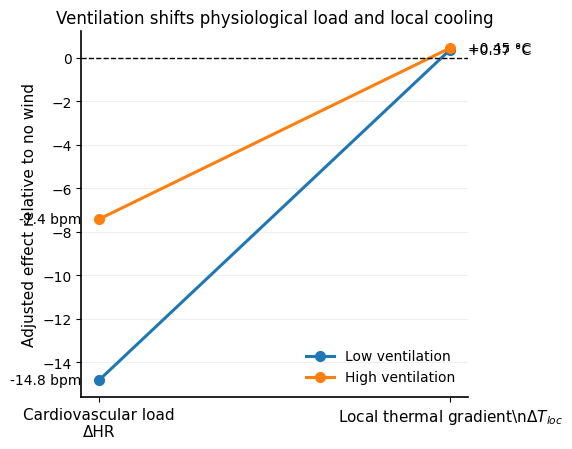

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ============================================================
# 1. Clean dataset
# ============================================================

analysis_df = dynamic_hr_df[
    [
        "subject_id",
        "condition",
        "phase",
        "HR_mean_bpm",
        "delta_t_loc_mean",
    ]
].dropna().copy()

PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]

CONDITION_ORDER = [
    "no_wind",
    "wind_low",
    "wind_high",
]

analysis_df["phase"] = pd.Categorical(
    analysis_df["phase"],
    categories=PHASE_ORDER,
    ordered=True,
)

analysis_df["condition"] = pd.Categorical(
    analysis_df["condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

analysis_df = analysis_df.sort_values(["condition", "phase", "subject_id"])

print("N observations:", len(analysis_df))
print("N subjects:", analysis_df["subject_id"].nunique())
print(analysis_df.groupby(["condition", "phase"]).size())


# ============================================================
# 2. Does ventilation affect cardiovascular load?
#    HR_mean_bpm ~ condition + phase
# ============================================================

hr_model = smf.ols(
    "HR_mean_bpm ~ C(condition) + C(phase)",
    data=analysis_df,
).fit(cov_type="HC3")

print(hr_model.summary())


# ============================================================
# 3. Does local thermal gradient depend on ventilation after HR?
#    delta_t_loc_mean ~ condition + phase + HR
# ============================================================

thermal_model = smf.ols(
    "delta_t_loc_mean ~ C(condition) + C(phase) + HR_mean_bpm",
    data=analysis_df,
).fit(cov_type="HC3")

print(thermal_model.summary())


# ============================================================
# 4. Single figure: HR vs local thermal gradient
# ============================================================

coef_data = pd.DataFrame([
    {
        "outcome": "Heart rate",
        "condition": "wind_low",
        "coef": -14.8195,
        "ci_low": -22.692,
        "ci_high": -6.947,
        "p": 0.000,
    },
    {
        "outcome": "Heart rate",
        "condition": "wind_high",
        "coef": -7.4211,
        "ci_low": -15.906,
        "ci_high": 1.064,
        "p": 0.087,
    },
    {
        "outcome": r"$\Delta T_{loc}$",
        "condition": "wind_low",
        "coef": 0.3731,
        "ci_low": -0.071,
        "ci_high": 0.818,
        "p": 0.100,
    },
    {
        "outcome": r"$\Delta T_{loc}$",
        "condition": "wind_high",
        "coef": 0.4455,
        "ci_low": 0.069,
        "ci_high": 0.822,
        "p": 0.020,
    },
])

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

for ax, outcome, xlabel in zip(
    axes,
    ["Heart rate", r"$\Delta T_{loc}$"],
    ["Effect on heart rate [bpm]", r"Effect on $\Delta T_{loc}$ [$^\circ$C]"],
):
    d = coef_data[coef_data["outcome"] == outcome].copy()
    y_pos = range(len(d))

    ax.errorbar(
        d["coef"],
        y_pos,
        xerr=[
            d["coef"] - d["ci_low"],
            d["ci_high"] - d["coef"],
        ],
        fmt="o",
        capsize=4,
        markersize=7,
        linewidth=2,
        color="black",
        ecolor="black",
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(d["condition"])
    ax.set_xlabel(xlabel)
    ax.set_title(outcome)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.savefig("ventilation_effects_HR_and_deltaTloc.png", dpi=300, bbox_inches="tight")
plt.show()